# Phase A V3 - Full Medical Document Suite

This notebook generates a broader synthetic benchmark suite covering the document types in the sample guide: prescriptions, hospital bills, lab reports, pharmacy bills, and handwritten prescription variants. Template preservation plus controlled degradation is a standard strategy for realistic synthetic document generation because it keeps document layout plausible while still producing exact ground truth for evaluation.[web:206][web:150][web:145]

## Scope

This notebook is still Phase A only: generate realistic document images and matching ground-truth JSON. The goal is to create a full benchmark corpus that later OCR notebooks can evaluate one document type and one quality track at a time.[web:206][web:205]

In [1]:
%pip install -U pip setuptools wheel
%pip install pillow faker numpy pandas opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import json
import random
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Any, Dict, List, Tuple
from datetime import datetime, timedelta

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from faker import Faker

fake = Faker('en_IN')
random.seed(42)
np.random.seed(42)

In [3]:
CONFIG = {
    'root_dir': './phase_a_v3_full_suite',
    'printed_docs_per_type': 20,
    'handwritten_docs_per_kind': 10,
    'page_width': 1654,
    'page_height': 2339,
    'margin': 72,
    'font_candidates_sans': [
        'C:/Windows/Fonts/arial.ttf',
        'C:/Windows/Fonts/calibri.ttf',
        '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
        '/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf',
    ],
    'font_candidates_bold': [
        'C:/Windows/Fonts/arialbd.ttf',
        'C:/Windows/Fonts/calibrib.ttf',
        '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
        '/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf',
    ],
    'hand_candidates': [
        'C:/Windows/Fonts/segoesc.ttf',
        'C:/Windows/Fonts/comic.ttf',
        '/usr/share/fonts/truetype/dejavu/DejaVuSerif-Italic.ttf',
        '/usr/share/fonts/truetype/liberation2/LiberationSerif-Italic.ttf',
    ]
}

ROOT = Path(CONFIG['root_dir'])
RAW_DIR = ROOT / 'raw'
VARIANT_DIR = ROOT / 'variants'
GT_DIR = ROOT / 'ground_truth'
MANIFEST_DIR = ROOT / 'manifests'
for p in [RAW_DIR, VARIANT_DIR, GT_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

In [4]:
DOCTORS = [('Dr. Arun Sharma', 'Internal Medicine'), ('Dr. Meena Pillai', 'Pathology'), ('Dr. Kiran Rao', 'General Medicine'), ('Dr. Priyanka Iyer', 'Pediatrics'), ('Dr. Sandeep Menon', 'Orthopedics'), ('Dr. Ritu Varma', 'Dermatology')]
HOSPITALS = ['City Medical Centre', 'Apollo Hospitals', 'Fortis Healthcare', 'Manipal Hospitals', 'Aster Clinics']
PHARMACIES = ['Health First Pharmacy', 'MediPlus Drug House', 'CareWell Pharmacy', 'Sri Lakshmi Medicals']
LABS = ['Precision Diagnostics Pvt Ltd', 'AccuLab Diagnostics', 'Prime Path Labs']
DIAGNOSES = ['Viral Fever', 'Hypertension', 'Type 2 Diabetes', 'Acute Bronchitis', 'UTI', 'Migraine', 'GERD', 'Dengue', 'Hypothyroidism']
MEDICINES = ['Paracetamol 650mg', 'Vitamin C 500mg', 'Azithromycin 500mg', 'Pantoprazole 40mg', 'Metformin 500mg', 'Cetirizine 10mg', 'Dolo 650mg', 'Amoxicillin 500mg', 'Cefixime 200mg', 'ORS Sachet']
TESTS = ['CBC', 'Dengue NS1', 'Blood Sugar Fasting', 'Urine Routine', 'X-Ray Chest', 'MRI Brain', 'CT Scan Abdomen', 'TSH', 'LFT']
HAND_NOTES = ['after food', 'before bed', 'twice daily', 'for 5 days', 'review in 3 days', 'if fever persists', 'with water', 'night only']
STATE_CODES = ['KA','MH','DL','TN','GJ','AP','UP','WB','KL']
AYUR_STATES = ['KL','TN','KA']

In [5]:
@dataclass
class DocRecord:
    doc_id: str
    doc_type: str
    variant_kind: str
    clean_image_path: str
    variants: List[Dict[str, Any]]
    ground_truth_path: str
    metadata: Dict[str, Any] = field(default_factory=dict)

In [6]:
def pick_font(paths, size):
    for p in paths:
        if Path(p).exists():
            return ImageFont.truetype(p, size=size)
    return ImageFont.load_default()

def fonts():
    return {
        'title': pick_font(CONFIG['font_candidates_bold'], 42),
        'h1': pick_font(CONFIG['font_candidates_bold'], 34),
        'body': pick_font(CONFIG['font_candidates_sans'], 24),
        'small': pick_font(CONFIG['font_candidates_sans'], 20),
        'tiny': pick_font(CONFIG['font_candidates_sans'], 17),
        'hand': pick_font(CONFIG['hand_candidates'], 30),
    }

def random_reg_no():
    if random.random() < 0.08:
        return f"AYUR/{random.choice(AYUR_STATES)}/{random.randint(1000,9999)}/{random.randint(2014,2026)}"
    return f"{random.choice(STATE_CODES)}/{random.randint(10000,99999)}/{random.randint(2010,2026)}"

def random_patient():
    gender = random.choice(['Male', 'Female'])
    name = fake.name_male() if gender == 'Male' else fake.name_female()
    return {'name': name, 'age': random.randint(6, 79), 'gender': gender}

def random_doctor():
    name, spec = random.choice(DOCTORS)
    return {'name': name, 'specialization': spec, 'reg_no': random_reg_no()}

def random_date():
    return datetime.now() - timedelta(days=random.randint(1, 540))

def bill_no(prefix):
    return f"{prefix}/{random.randint(2024,2026)}/{random.randint(1000,99999)}"

def paper_canvas():
    bg = np.full((CONFIG['page_height'], CONFIG['page_width'], 3), random.choice([248, 251, 255]), dtype=np.uint8)
    noise = np.random.normal(0, 3, bg.shape).astype(np.int16)
    return Image.fromarray(np.clip(bg.astype(np.int16) + noise, 0, 255).astype(np.uint8))

def draw_box(draw, xy, outline=(70,70,70), width=2, fill=None):
    draw.rectangle(xy, outline=outline, width=width, fill=fill)

def draw_header(draw, fp, x, y, title, subtitle, extra=''):
    draw.text((x, y), title, fill=(15,15,15), font=fp['title'])
    draw.text((x, y+50), subtitle, fill=(55,55,55), font=fp['small'])
    if extra:
        draw.text((x, y+84), extra, fill=(60,60,60), font=fp['small'])
    draw.line((x, y+122, CONFIG['page_width']-x, y+122), fill=(20,20,20), width=2)

In [7]:
def render_word_image(word, fp, ink=(25,50,125), pad=20):
    temp = Image.new('RGBA', (max(220, len(word)*28), 90), (255,255,255,0))
    d = ImageDraw.Draw(temp)
    x, y = pad, 18
    for idx, ch in enumerate(word):
        ch_x = x + idx * random.randint(16, 21)
        ch_y = y + random.randint(-2, 2)
        d.text((ch_x, ch_y), ch, fill=ink, font=fp['hand'])
        if idx < len(word)-1 and ch.isalpha():
            d.line((ch_x+14, ch_y+28, ch_x+26, ch_y+30), fill=ink, width=2)
    bbox = temp.getbbox() or (0,0,temp.width,temp.height)
    return temp.crop(bbox)

def paste_word(base, word_img, x, y, angle=0):
    w = word_img.rotate(angle, resample=Image.Resampling.BICUBIC, expand=True)
    base.paste(w, (int(x), int(y)), w)
    return w.size

def draw_cursive_line(base, text, x, y, fp, tier='neat', ink=(25,50,125)):
    settings = {'neat': {'angle': 2, 'gap': (18, 28), 'baseline': 2}, 'fast': {'angle': 4, 'gap': (14, 22), 'baseline': 4}, 'doctor': {'angle': 6, 'gap': (12, 18), 'baseline': 5}}[tier]
    cursor_x = x
    for word in text.split():
        wimg = render_word_image(word, fp, ink=ink)
        angle = random.uniform(-settings['angle'], settings['angle'])
        dy = random.randint(-settings['baseline'], settings['baseline'])
        w, h = paste_word(base, wimg, cursor_x, y+dy, angle=angle)
        cursor_x += w + random.randint(*settings['gap'])

def draw_signature(base, name, x, y, fp):
    draw_cursive_line(base, name.replace('Dr. ', 'Dr '), x, y, fp, tier='doctor', ink=(30,45,120))

def draw_round_stamp(img, x, y, text='SIGNED'):
    overlay = Image.new('RGBA', img.size, (255,255,255,0))
    d = ImageDraw.Draw(overlay)
    r = 90
    d.ellipse((x-r, y-r, x+r, y+r), outline=(180,0,0,150), width=5)
    d.ellipse((x-r+15, y-r+15, x+r-15, y+r-15), outline=(180,0,0,110), width=2)
    d.text((x-42, y-12), text, fill=(180,0,0,130), font=pick_font(CONFIG['font_candidates_bold'], 26))
    return Image.alpha_composite(img.convert('RGBA'), overlay).convert('RGB')

In [8]:
def make_prescription_payload(kind='printed'):
    patient = random_patient()
    doctor = random_doctor()
    dt = random_date()
    meds = []
    for m in random.sample(MEDICINES, k=random.randint(2,4)):
        meds.append({'name': m, 'dosage': random.choice(['1-0-1','1-1-1','0-0-1','SOS']), 'duration_days': random.randint(3, 10), 'note': random.choice(HAND_NOTES)})
    return {'kind': kind, 'hospital': random.choice(HOSPITALS), 'doctor': doctor, 'patient': patient, 'date': dt.strftime('%d-%b-%Y'), 'date_iso': dt.date().isoformat(), 'diagnosis': random.choice(DIAGNOSES), 'medicines': meds, 'tests': random.sample(TESTS, k=random.randint(1,3)), 'doctor_note': random.choice(HAND_NOTES), 'phone': fake.msisdn()[:10], 'complaint': random.choice(['Fever since 3 days, body ache', 'Cough with sore throat', 'Headache and nausea', 'Burning micturition'])}

def make_hospital_bill_payload():
    patient = random_patient()
    doctor = random_doctor()
    dt = random_date()
    items = [('Consultation Fee (OPD)', 1, random.choice([500,800,1000,1200])), ('CBC (Complete Blood Count)', 1, 200), ('Dengue NS1 Antigen Test', 1, 300), ('Medicines', 1, random.choice([250,350,450]))]
    line_items, subtotal = [], 0
    for desc, qty, rate in items:
        amt = qty * rate
        subtotal += amt
        line_items.append({'description': desc, 'qty': qty, 'rate': rate, 'amount': amt})
    gst = 0.0 if random.random() < 0.8 else round(subtotal * 0.05, 2)
    total = round(subtotal + gst, 2)
    return {'hospital': random.choice(HOSPITALS), 'address': '12 MG Road, Bengaluru - 560001', 'gstin': None if random.random() < 0.25 else '29ABCDE1234F1ZX', 'bill_no': bill_no('CMC'), 'date': dt.strftime('%d-%b-%Y'), 'date_iso': dt.date().isoformat(), 'patient': patient, 'doctor': doctor, 'line_items': line_items, 'subtotal': subtotal, 'gst_amount': gst, 'total_amount': total, 'payment_mode': random.choice(['Cash', 'UPI', 'Card'])}

def make_lab_report_payload():
    patient = random_patient()
    doctor = random_doctor()
    pathologist = random_doctor()
    sdt = random_date()
    rdt = sdt + timedelta(hours=random.randint(2, 24))
    test_rows = random.sample([('Hemoglobin', '13.2', 'g/dL', '13.0 - 17.0'), ('WBC Count', '9,800', '/uL', '4,500 - 11,000'), ('Platelet Count', '185,000', '/uL', '150,000 - 450,000'), ('Dengue NS1 Antigen', 'NEGATIVE', '-', '-'), ('Blood Sugar Fasting', '102', 'mg/dL', '70 - 100')], k=random.randint(3,5))
    return {'lab_name': random.choice(LABS), 'nabl_status': random.choice(['NABL Accredited Lab', 'NABL Applied', 'NABL Accredited Lab']), 'lab_id': 'KA-NABL-1234', 'address': '45 Jayanagar, Bengaluru', 'patient': patient, 'doctor': doctor, 'pathologist': pathologist, 'sample_date': sdt.strftime('%d-%b-%Y'), 'sample_date_iso': sdt.date().isoformat(), 'report_date': rdt.strftime('%d-%b-%Y'), 'report_date_iso': rdt.date().isoformat(), 'sample_id': f"PD-{random.randint(2024,2026)}-{random.randint(10000,99999)}", 'tests': test_rows, 'remarks': random.choice(['Clinical correlation advised.', 'WBC count is towards upper normal limit.', 'Repeat test if symptoms persist.'])}

def make_pharmacy_bill_payload():
    patient = random_patient()
    doctor = random_doctor()
    dt = random_date()
    meds, subtotal = [], 0
    for m in random.sample(MEDICINES, k=random.randint(2,4)):
        qty = random.randint(5, 20)
        mrp = random.choice([2.50,4.00,5.50,8.00,12.00])
        amt = round(qty * mrp, 2)
        subtotal += amt
        meds.append({'name': m, 'batch': random.choice(['A2341','B7821','C1920']), 'expiry': random.choice(['03/26','06/26','11/27']), 'qty': qty, 'mrp': mrp, 'amount': amt})
    discount = round(subtotal * random.choice([0, 0.05, 0.10]), 2)
    net = round(subtotal - discount, 2)
    return {'pharmacy': random.choice(PHARMACIES), 'license_no': f"KA-BLR-{random.randint(1000,9999)}", 'address': '22 Brigade Road, Bengaluru', 'bill_no': bill_no('HFP'), 'date': dt.strftime('%d-%b-%Y'), 'date_iso': dt.date().isoformat(), 'patient': patient, 'doctor': doctor, 'medicines': meds, 'subtotal': round(subtotal,2), 'discount': discount, 'net_amount': net}

In [9]:
def render_prescription(payload, out_png):
    fp = fonts()
    img = paper_canvas()
    draw = ImageDraw.Draw(img)
    x, y = CONFIG['margin'], 48
    draw_header(draw, fp, x, y, payload['doctor']['name'], f"MBBS, MD ({payload['doctor']['specialization']}) | Reg No: {payload['doctor']['reg_no']}", f"{payload['hospital']}, Bengaluru | Ph: {payload['phone']}")
    info_y = y + 160
    draw_box(draw, (x, info_y, CONFIG['page_width']-x, info_y+150))
    draw.text((x+18, info_y+16), f"Patient: {payload['patient']['name']}", fill='black', font=fp['body'])
    draw.text((x+18, info_y+54), f"Age: {payload['patient']['age']} years   Gender: {payload['patient']['gender'][0]}", fill='black', font=fp['body'])
    draw.text((CONFIG['page_width']//2, info_y+16), f"Date: {payload['date']}", fill='black', font=fp['body'])
    draw.text((x+18, info_y+92), f"Chief Complaint: {payload['complaint']}", fill='black', font=fp['small'])
    rx_y = info_y + 185
    draw.text((x+10, rx_y), 'Diagnosis:', fill='black', font=fp['body'])
    draw.text((x+180, rx_y), payload['diagnosis'], fill='black', font=fp['body'])
    draw.text((x+10, rx_y+60), 'Rx:', fill=(20,30,120), font=fp['h1'])
    line_y = rx_y + 120
    if payload['kind'] == 'printed':
        for idx, med in enumerate(payload['medicines'], start=1):
            draw.text((x+28, line_y), f"{idx}. Tab {med['name']} - {med['dosage']} x {med['duration_days']} days", fill='black', font=fp['body'])
            line_y += 54
        draw.text((x+28, line_y+18), f"Investigations: {', '.join(payload['tests'])}", fill='black', font=fp['body'])
        draw.text((x+28, line_y+72), f"Follow-up: {payload['doctor_note']}", fill='black', font=fp['body'])
    else:
        tier = {'mixed_cursive':'neat', 'fast_cursive':'fast', 'doctor_cursive':'doctor'}[payload['kind']]
        if payload['kind'] == 'mixed_cursive':
            for idx, med in enumerate(payload['medicines'], start=1):
                draw.text((x+28, line_y), f"{idx}. {med['name']}", fill='black', font=fp['body'])
                draw_cursive_line(img, f"{med['dosage']} for {med['duration_days']} days {med['note']}", x+720, line_y-6, fp, tier=tier)
                line_y += 58
        else:
            for idx, med in enumerate(payload['medicines'], start=1):
                draw.text((x+28, line_y), f"{idx}.", fill='black', font=fp['body'])
                draw_cursive_line(img, f"{med['name']} {med['dosage']} for {med['duration_days']} days {med['note']}", x+90, line_y-8, fp, tier=tier)
                line_y += 70 if tier == 'doctor' else 62
        draw.text((x+28, line_y+18), f"Investigations: {', '.join(payload['tests'])}", fill='black', font=fp['body'])
        draw_cursive_line(img, payload['doctor_note'], x+28, line_y+70, fp, tier=tier)
    draw_signature(img, payload['doctor']['name'], CONFIG['page_width']-430, CONFIG['page_height']-240, fp)
    img = draw_round_stamp(img, CONFIG['page_width']-270, CONFIG['page_height']-320, random.choice(['SIGNED','VERIFIED']))
    img.save(out_png)
    lines = [payload['doctor']['name'], f"Reg No: {payload['doctor']['reg_no']}", payload['hospital'], f"Patient: {payload['patient']['name']}", f"Age: {payload['patient']['age']} years", f"Gender: {payload['patient']['gender']}", f"Date: {payload['date']}", f"Chief Complaint: {payload['complaint']}", f"Diagnosis: {payload['diagnosis']}"] + [f"{m['name']} | {m['dosage']} | {m['duration_days']} days | {m['note']}" for m in payload['medicines']] + [f"Investigations: {', '.join(payload['tests'])}", f"Follow-up: {payload['doctor_note']}"]
    gt = {'doctor_name': payload['doctor']['name'], 'doctor_reg_no': payload['doctor']['reg_no'], 'specialization': payload['doctor']['specialization'], 'patient_name': payload['patient']['name'], 'age': payload['patient']['age'], 'gender': payload['patient']['gender'], 'date': payload['date_iso'], 'chief_complaint': payload['complaint'], 'diagnosis': payload['diagnosis'], 'medicines': payload['medicines'], 'tests': payload['tests'], 'hospital_name': payload['hospital'], 'handwriting_style': payload['kind']}
    return lines, gt

def render_hospital_bill(payload, out_png):
    fp = fonts()
    img = paper_canvas()
    draw = ImageDraw.Draw(img)
    x, y = CONFIG['margin'], 48
    subtitle = payload['address'] if payload['gstin'] is None else f"{payload['address']} | GSTIN: {payload['gstin']}"
    draw_header(draw, fp, x, y, payload['hospital'].upper(), subtitle, 'Ph: 080-XXXXXXXX')
    draw.text((CONFIG['page_width']-380, y+20), 'BILL / RECEIPT', fill='black', font=fp['h1'])
    info_y = y + 160
    draw_box(draw, (x, info_y, CONFIG['page_width']-x, info_y+150))
    draw.text((x+18, info_y+16), f"Bill No: {payload['bill_no']}", fill='black', font=fp['body'])
    draw.text((x+18, info_y+54), f"Date: {payload['date']}", fill='black', font=fp['body'])
    draw.text((x+18, info_y+92), f"Patient Name: {payload['patient']['name']}", fill='black', font=fp['body'])
    draw.text((CONFIG['page_width']//2, info_y+16), f"Age/Gender: {payload['patient']['age']} / {payload['patient']['gender']}", fill='black', font=fp['body'])
    draw.text((CONFIG['page_width']//2, info_y+54), f"Referring Doctor: {payload['doctor']['name']}", fill='black', font=fp['body'])
    table_y = info_y + 190
    left, right = x, CONFIG['page_width'] - x
    cols = [left, left+760, left+880, left+1040, right]
    draw_box(draw, (left, table_y, right, table_y+58), fill=(243,243,243))
    for c in cols[1:-1]: draw.line((c, table_y, c, table_y+58), fill=(80,80,80), width=2)
    heads = ['DESCRIPTION', 'QTY', 'RATE', 'AMOUNT']
    for i, h in enumerate(heads): draw.text((cols[i]+14, table_y+14), h, font=fp['small'], fill='black')
    row_y = table_y + 58
    for item in payload['line_items']:
        draw_box(draw, (left, row_y, right, row_y+52), width=1)
        for c in cols[1:-1]: draw.line((c, row_y, c, row_y+52), fill=(100,100,100), width=1)
        vals = [item['description'], str(item['qty']), f"{item['rate']:.2f}", f"{item['amount']:.2f}"]
        for i, val in enumerate(vals): draw.text((cols[i]+12, row_y+12), val, font=fp['small'], fill='black')
        row_y += 52
    sum_y = row_y + 26
    draw_box(draw, (CONFIG['page_width']-540, sum_y, CONFIG['page_width']-x, sum_y+170))
    draw.text((CONFIG['page_width']-520, sum_y+18), f"Subtotal: {payload['subtotal']:.2f}", font=fp['body'], fill='black')
    draw.text((CONFIG['page_width']-520, sum_y+58), f"GST: {payload['gst_amount']:.2f}", font=fp['body'], fill='black')
    draw.text((CONFIG['page_width']-520, sum_y+98), f"Total Amount: {payload['total_amount']:.2f}", font=fp['h1'], fill='black')
    draw.text((x+18, sum_y+18), f"Payment Mode: {payload['payment_mode']}", font=fp['body'], fill='black')
    img = draw_round_stamp(img, CONFIG['page_width']-280, CONFIG['page_height']-300, random.choice(['PAID','RECEIVED']))
    img.save(out_png)
    lines = [payload['hospital'], payload['address'], f"GSTIN: {payload['gstin'] or ''}", f"Bill No: {payload['bill_no']}", f"Date: {payload['date']}", f"Patient Name: {payload['patient']['name']}", f"Age/Gender: {payload['patient']['age']} / {payload['patient']['gender']}"] + [f"{it['description']} {it['qty']} {it['rate']:.2f} {it['amount']:.2f}" for it in payload['line_items']] + [f"Subtotal: {payload['subtotal']:.2f}", f"GST: {payload['gst_amount']:.2f}", f"Total Amount: {payload['total_amount']:.2f}"]
    gt = payload.copy()
    gt['patient_name'] = payload['patient']['name']
    gt['age'] = payload['patient']['age']
    gt['gender'] = payload['patient']['gender']
    gt['bill_date'] = payload['date_iso']
    return lines, gt

def render_lab_report(payload, out_png):
    fp = fonts()
    img = paper_canvas()
    draw = ImageDraw.Draw(img)
    x, y = CONFIG['margin'], 48
    draw_header(draw, fp, x, y, payload['lab_name'].upper(), f"{payload['nabl_status']} | Lab ID: {payload['lab_id']}", payload['address'])
    info_y = y + 160
    draw_box(draw, (x, info_y, CONFIG['page_width']-x, info_y+160))
    draw.text((x+18, info_y+18), f"Patient: {payload['patient']['name']}", fill='black', font=fp['body'])
    draw.text((x+18, info_y+54), f"Age/Sex: {payload['patient']['age']} / {payload['patient']['gender']}", fill='black', font=fp['body'])
    draw.text((x+18, info_y+90), f"Ref Doctor: {payload['doctor']['name']}", fill='black', font=fp['body'])
    draw.text((CONFIG['page_width']//2, info_y+18), f"Sample Date: {payload['sample_date']}", fill='black', font=fp['body'])
    draw.text((CONFIG['page_width']//2, info_y+54), f"Report Date: {payload['report_date']}", fill='black', font=fp['body'])
    draw.text((CONFIG['page_width']//2, info_y+90), f"Sample ID: {payload['sample_id']}", fill='black', font=fp['body'])
    table_y = info_y + 190
    left, right = x, CONFIG['page_width']-x
    cols = [left, left+640, left+860, left+1040, right]
    draw_box(draw, (left, table_y, right, table_y+58), fill=(243,243,243))
    for c in cols[1:-1]: draw.line((c, table_y, c, table_y+58), fill=(80,80,80), width=2)
    for i, h in enumerate(['TEST NAME','RESULT','UNIT','NORMAL RANGE']): draw.text((cols[i]+14, table_y+14), h, font=fp['small'], fill='black')
    row_y = table_y + 58
    for t in payload['tests']:
        draw_box(draw, (left, row_y, right, row_y+52), width=1)
        for c in cols[1:-1]: draw.line((c, row_y, c, row_y+52), fill=(100,100,100), width=1)
        vals = [t[0], t[1], t[2], t[3]]
        for i, val in enumerate(vals): draw.text((cols[i]+12, row_y+12), str(val), font=fp['small'], fill='black')
        row_y += 52
    draw.text((x, row_y+36), f"Remarks: {payload['remarks']}", fill='black', font=fp['body'])
    draw_signature(img, payload['pathologist']['name'], CONFIG['page_width']-470, CONFIG['page_height']-250, fp)
    img = draw_round_stamp(img, CONFIG['page_width']-300, CONFIG['page_height']-320, 'STAMP')
    img.save(out_png)
    lines = [payload['lab_name'], payload['nabl_status'], f"Patient: {payload['patient']['name']}", f"Age/Sex: {payload['patient']['age']} / {payload['patient']['gender']}", f"Ref Doctor: {payload['doctor']['name']}", f"Sample Date: {payload['sample_date']}", f"Report Date: {payload['report_date']}", f"Sample ID: {payload['sample_id']}"] + [f"{t[0]} {t[1]} {t[2]} {t[3]}" for t in payload['tests']] + [f"Remarks: {payload['remarks']}", payload['pathologist']['name'], f"Reg No: {payload['pathologist']['reg_no']}"]
    gt = {'lab_name': payload['lab_name'], 'nabl_status': payload['nabl_status'], 'patient_name': payload['patient']['name'], 'age': payload['patient']['age'], 'gender': payload['patient']['gender'], 'doctor_name': payload['doctor']['name'], 'sample_date': payload['sample_date_iso'], 'report_date': payload['report_date_iso'], 'sample_id': payload['sample_id'], 'tests': [{'name': t[0], 'result': t[1], 'unit': t[2], 'range': t[3]} for t in payload['tests']], 'pathologist_name': payload['pathologist']['name'], 'pathologist_reg_no': payload['pathologist']['reg_no'], 'remarks': payload['remarks']}
    return lines, gt

def render_pharmacy_bill(payload, out_png):
    fp = fonts()
    img = paper_canvas()
    draw = ImageDraw.Draw(img)
    x, y = CONFIG['margin'] + 120, 30
    receipt_width = CONFIG['page_width'] - 2*x
    draw_box(draw, (x-20, y-10, x+receipt_width+20, CONFIG['page_height']-45), outline=(120,120,120), width=1)
    draw.text((x + 120, y), payload['pharmacy'].upper(), font=fp['h1'], fill='black')
    draw.text((x + 60, y+40), payload['address'], font=fp['small'], fill=(60,60,60))
    draw.text((x + 100, y+72), f"Drug Lic. No: {payload['license_no']}", font=fp['small'], fill=(60,60,60))
    draw.line((x, y+112, x+receipt_width, y+112), fill='black', width=2)
    ty = y + 130
    for line in [f"Bill No: {payload['bill_no']}", f"Date: {payload['date']}", f"Patient: {payload['patient']['name']}", f"Dr: {payload['doctor']['name']}"]:
        draw.text((x, ty), line, font=fp['body'], fill='black')
        ty += 36
    draw.line((x, ty+6, x+receipt_width, ty+6), fill='black', width=1)
    ty += 24
    headers = [('MEDICINE',0), ('BATCH',330), ('EXP',470), ('QTY',590), ('MRP',680), ('AMT',810)]
    for h, off in headers: draw.text((x+off, ty), h, font=fp['small'], fill='black')
    ty += 28
    draw.line((x, ty, x+receipt_width, ty), fill='black', width=1)
    ty += 18
    for med in payload['medicines']:
        draw.text((x, ty), med['name'], font=fp['small'], fill='black')
        draw.text((x+330, ty), med['batch'], font=fp['small'], fill='black')
        draw.text((x+470, ty), med['expiry'], font=fp['small'], fill='black')
        draw.text((x+590, ty), str(med['qty']), font=fp['small'], fill='black')
        draw.text((x+680, ty), f"{med['mrp']:.2f}", font=fp['small'], fill='black')
        draw.text((x+810, ty), f"{med['amount']:.2f}", font=fp['small'], fill='black')
        ty += 34
    draw.line((x, ty+8, x+receipt_width, ty+8), fill='black', width=1)
    draw.text((x+560, ty+30), f"Subtotal: {payload['subtotal']:.2f}", font=fp['body'], fill='black')
    draw.text((x+560, ty+66), f"Discount: -{payload['discount']:.2f}", font=fp['body'], fill='black')
    draw.text((x+560, ty+106), f"Net Amount: {payload['net_amount']:.2f}", font=fp['h1'], fill='black')
    draw_signature(img, 'R. Sharma', x+560, CONFIG['page_height']-210, fp)
    img = draw_round_stamp(img, x+250, CONFIG['page_height']-220, 'STAMP')
    img.save(out_png)
    lines = [payload['pharmacy'], payload['address'], f"Drug Lic. No: {payload['license_no']}", f"Bill No: {payload['bill_no']}", f"Date: {payload['date']}", f"Patient: {payload['patient']['name']}", f"Dr: {payload['doctor']['name']}"] + [f"{m['name']} {m['batch']} {m['expiry']} {m['qty']} {m['mrp']:.2f} {m['amount']:.2f}" for m in payload['medicines']] + [f"Subtotal: {payload['subtotal']:.2f}", f"Discount: -{payload['discount']:.2f}", f"Net Amount: {payload['net_amount']:.2f}"]
    gt = {'pharmacy_name': payload['pharmacy'], 'drug_license_no': payload['license_no'], 'bill_no': payload['bill_no'], 'date': payload['date_iso'], 'patient_name': payload['patient']['name'], 'doctor_name': payload['doctor']['name'], 'medicines': payload['medicines'], 'subtotal': payload['subtotal'], 'discount': payload['discount'], 'net_amount': payload['net_amount']}
    return lines, gt

In [10]:
def add_blur(img, severity=1):
    kernel = {1: 3, 2: 5}.get(severity, 3)
    return cv2.GaussianBlur(img, (kernel, kernel), 0)

def add_noise(img, severity=1):
    sigma = {1: 6, 2: 12}.get(severity, 6)
    noise = np.random.normal(0, sigma, img.shape).astype(np.int16)
    return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

def add_rotation(img, severity=1):
    angle = {1: 2, 2: 4}.get(severity, 2) * random.choice([-1,1])
    h, w = img.shape[:2]
    m = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, m, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(255,255,255))

def add_shadow(img, severity=1):
    overlay = img.copy().astype(np.float32)
    h, w = img.shape[:2]
    alpha = {1: 0.12, 2: 0.22}.get(severity, 0.12)
    x1 = random.randint(0, int(w * 0.3))
    x2 = random.randint(int(w * 0.55), w)
    cv2.rectangle(overlay, (x1, 0), (x2, h), (35,35,35), -1)
    return np.clip(cv2.addWeighted(overlay, alpha, img.astype(np.float32), 1-alpha, 0), 0, 255).astype(np.uint8)

AUGS = {'blur': add_blur, 'noise': add_noise, 'rotation': add_rotation, 'shadow': add_shadow}

def make_variants(doc_id, clean_image_path):
    out_dir = VARIANT_DIR / doc_id
    out_dir.mkdir(parents=True, exist_ok=True)
    base = cv2.imread(str(clean_image_path))
    rows = []
    for i, (name, sev) in enumerate([('blur',1), ('noise',1), ('rotation',1), ('shadow',1)], start=1):
        out = AUGS[name](base.copy(), severity=sev)
        out_path = out_dir / f"{doc_id}_{i:02d}_{name}.png"
        cv2.imwrite(str(out_path), out)
        rows.append({'variant_path': str(out_path), 'augmentation': name, 'severity': sev})
    return rows

def save_gt(doc_id, doc_type, variant_kind, lines, gt, clean_image_path, variants):
    payload = {'doc_id': doc_id, 'doc_type': doc_type, 'variant_kind': variant_kind, 'text_ground_truth': '\n'.join(lines), 'fields_ground_truth': gt, 'clean_image_path': str(clean_image_path), 'variants': variants}
    gt_path = GT_DIR / f"{doc_id}.json"
    gt_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False, default=str), encoding='utf-8')
    return gt_path

In [11]:
def generate_dataset():
    rows = []
    specs = [
        ('PRESCRIPTION', 'printed', CONFIG['printed_docs_per_type']),
        ('HOSPITAL_BILL', 'printed', CONFIG['printed_docs_per_type']),
        ('LAB_REPORT', 'printed', CONFIG['printed_docs_per_type']),
        ('PHARMACY_BILL', 'printed', CONFIG['printed_docs_per_type']),
        ('PRESCRIPTION', 'mixed_cursive', CONFIG['handwritten_docs_per_kind']),
        ('PRESCRIPTION', 'fast_cursive', CONFIG['handwritten_docs_per_kind']),
        ('PRESCRIPTION', 'doctor_cursive', CONFIG['handwritten_docs_per_kind']),
    ]
    counters = {}
    for doc_type, variant_kind, count in specs:
        raw_dir = RAW_DIR / doc_type
        raw_dir.mkdir(parents=True, exist_ok=True)
        for _ in range(count):
            counters[(doc_type, variant_kind)] = counters.get((doc_type, variant_kind), 0) + 1
            idx = counters[(doc_type, variant_kind)]
            doc_id = f"{doc_type.lower()}_{variant_kind}_{idx:03d}"
            clean_png = raw_dir / f"{doc_id}.png"
            if doc_type == 'PRESCRIPTION':
                payload = make_prescription_payload(kind=variant_kind)
                lines, gt = render_prescription(payload, clean_png)
            elif doc_type == 'HOSPITAL_BILL':
                payload = make_hospital_bill_payload()
                lines, gt = render_hospital_bill(payload, clean_png)
            elif doc_type == 'LAB_REPORT':
                payload = make_lab_report_payload()
                lines, gt = render_lab_report(payload, clean_png)
            else:
                payload = make_pharmacy_bill_payload()
                lines, gt = render_pharmacy_bill(payload, clean_png)
            variants = make_variants(doc_id, clean_png)
            gt_path = save_gt(doc_id, doc_type, variant_kind, lines, gt, clean_png, variants)
            rows.append(asdict(DocRecord(doc_id=doc_id, doc_type=doc_type, variant_kind=variant_kind, clean_image_path=str(clean_png), variants=variants, ground_truth_path=str(gt_path), metadata={'variant_count': len(variants)})))
    df = pd.DataFrame(rows)
    df.to_csv(MANIFEST_DIR / 'phase_a_v3_manifest.csv', index=False)
    return df

In [12]:
manifest_df = generate_dataset()
manifest_df[['doc_id','doc_type','variant_kind','clean_image_path']].head()

,doc_id,doc_type,variant_kind,clean_image_path
0,prescription_printed_001,PRESCRIPTION,printed,phase_a_v3_full_suite\raw\PRESCRIPTION\prescri...
1,prescription_printed_002,PRESCRIPTION,printed,phase_a_v3_full_suite\raw\PRESCRIPTION\prescri...
2,prescription_printed_003,PRESCRIPTION,printed,phase_a_v3_full_suite\raw\PRESCRIPTION\prescri...
3,prescription_printed_004,PRESCRIPTION,printed,phase_a_v3_full_suite\raw\PRESCRIPTION\prescri...
4,prescription_printed_005,PRESCRIPTION,printed,phase_a_v3_full_suite\raw\PRESCRIPTION\prescri...


In [13]:
manifest_df.groupby(['doc_type','variant_kind']).size()

doc_type       variant_kind  
HOSPITAL_BILL  printed           20
LAB_REPORT     printed           20
PHARMACY_BILL  printed           20
PRESCRIPTION   doctor_cursive    10
               fast_cursive      10
               mixed_cursive     10
               printed           20
dtype: int64

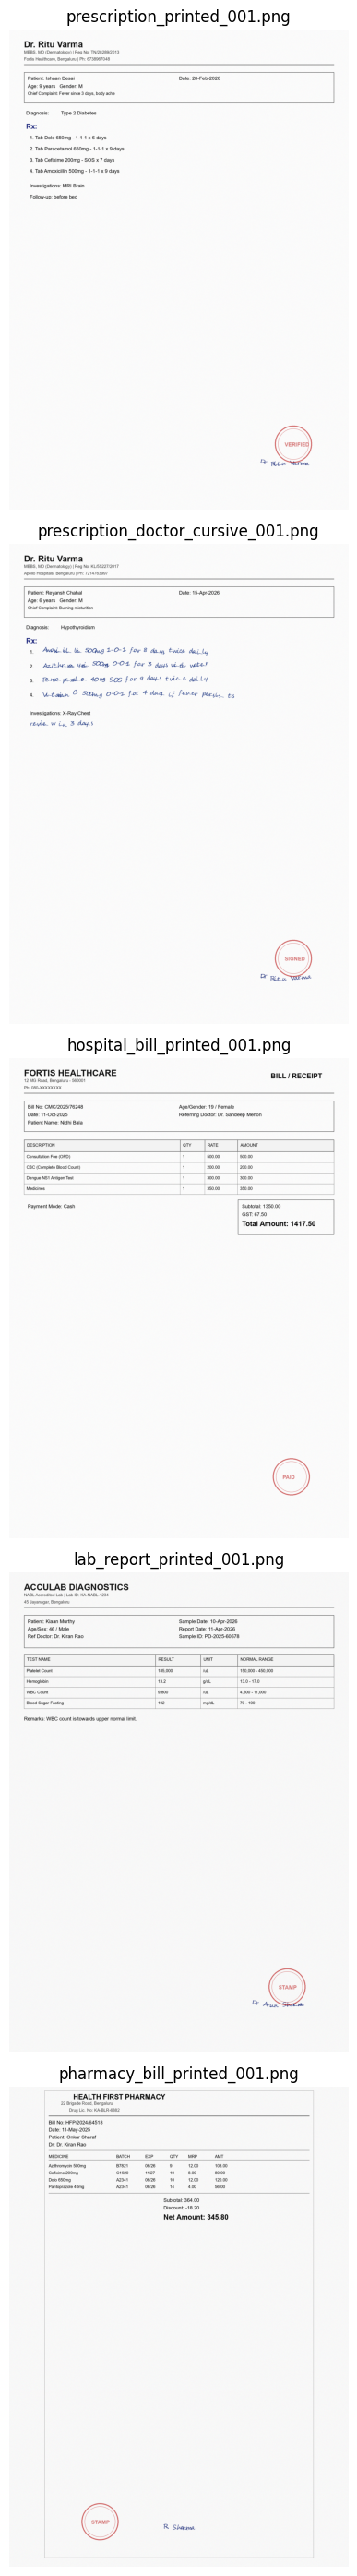

In [14]:
sample_rows = []
for key in [('PRESCRIPTION','printed'), ('PRESCRIPTION','doctor_cursive'), ('HOSPITAL_BILL','printed'), ('LAB_REPORT','printed'), ('PHARMACY_BILL','printed')]:
    sub = manifest_df[(manifest_df['doc_type']==key[0]) & (manifest_df['variant_kind']==key[1])].head(1)
    if len(sub):
        sample_rows.append(Path(sub.iloc[0]['clean_image_path']))

fig, axes = plt.subplots(len(sample_rows), 1, figsize=(15, 28))
if len(sample_rows) == 1:
    axes = [axes]
for ax, p in zip(axes, sample_rows):
    ax.imshow(Image.open(p))
    ax.set_title(p.name)
    ax.axis('off')
plt.tight_layout()

## Coverage

This notebook covers the main document types from the sample guide: printed prescriptions, hospital bills, lab reports, pharmacy bills, plus three cursive prescription tracks. The result is a single benchmark suite with multiple structures and difficulty modes instead of only one prescription-focused dataset.[web:206][web:210][web:205]

## Next phase

Phase B should evaluate OCR separately by document type and by variant kind, because structured medical forms and handwritten prescriptions fail in different ways and should not be scored together as one pool.[web:205][web:207]